# 13 Four Gates with No Line

| | |
|---|---|
| **Path** | Perceptron |
| **Prerequisite** | 12 |

Four gates, two bits each:

| Gate | $(x_1, x_2)$ | Label |
|---|---|---|
| 00 | $(0, 0)$ | fail, $-1$ |
| 10 | $(1, 0)$ | pass, $+1$ |
| 01 | $(0, 1)$ | pass, $+1$ |
| 11 | $(1, 1)$ | fail, $-1$ |

Opposite corners share a label. Suppose a weight pair could still be strictly correct:

$$
\begin{aligned}
b &< 0 \\
w_1 + b &> 0 \\
w_2 + b &> 0 \\
w_1 + w_2 + b &< 0
\end{aligned}
$$

Add the two pass inequalities:

$$
w_1 + w_2 + 2b > 0
$$

The last gate says $w_1 + w_2 < -b$. Substitute that into the sum:

$$
w_1 + w_2 + 2b < -b + 2b = b
$$

The bias is negative, so

$$
w_1 + w_2 + 2b < b < 0
$$

A negative number cannot be the positive sum $w_1 + w_2 + 2b$. No such weights exist. The picture is the same fact: one straight cut cannot put both fail gates on one side and both pass gates on the other.


## Example 1 — Four updates return to the start

Start at $(0, 0, 0)$ and visit 00, 10, 01, 11.

$$
\begin{aligned}
(0, 0, 0) &\xrightarrow{00} (0, 0, -1) \\
(0, 0, -1) &\xrightarrow{10} (1, 0, 0) \\
(1, 0, 0) &\xrightarrow{01} (1, 1, 1) \\
(1, 1, 1) &\xrightarrow{11} (0, 0, 0)
\end{aligned}
$$

The fourth update restores the zero vector. The next pass repeats the same four updates. The bound of Lesson 09 does not apply, because that bound needed a separator, and the proof above says there is none.


In [1]:
# Hand cycle: (0, 0, -1), (1, 0, 0), (1, 1, 1), then back to (0, 0, 0).
gates = [((0, 0), -1), ((1, 0), 1), ((0, 1), 1), ((1, 1), -1)]
weights = [0, 0, 0]
steps = []
for _ in range(2):
    for (x1, x2), label in gates:
        phi = (x1, x2, 1)
        if label * sum(weights[i] * phi[i] for i in range(3)) <= 0:
            weights = [weights[i] + label * phi[i] for i in range(3)]
            steps.append(tuple(weights))
print(steps)
assert steps == [
    (0, 0, -1),
    (1, 0, 0),
    (1, 1, 1),
    (0, 0, 0),
    (0, 0, -1),
    (1, 0, 0),
    (1, 1, 1),
    (0, 0, 0),
]


[(0, 0, -1), (1, 0, 0), (1, 1, 1), (0, 0, 0), (0, 0, -1), (1, 0, 0), (1, 1, 1), (0, 0, 0)]


## Example 2 — The four corners

Fail is clay. Pass is green. The two clay gates are opposite each other, and so are the two green gates.


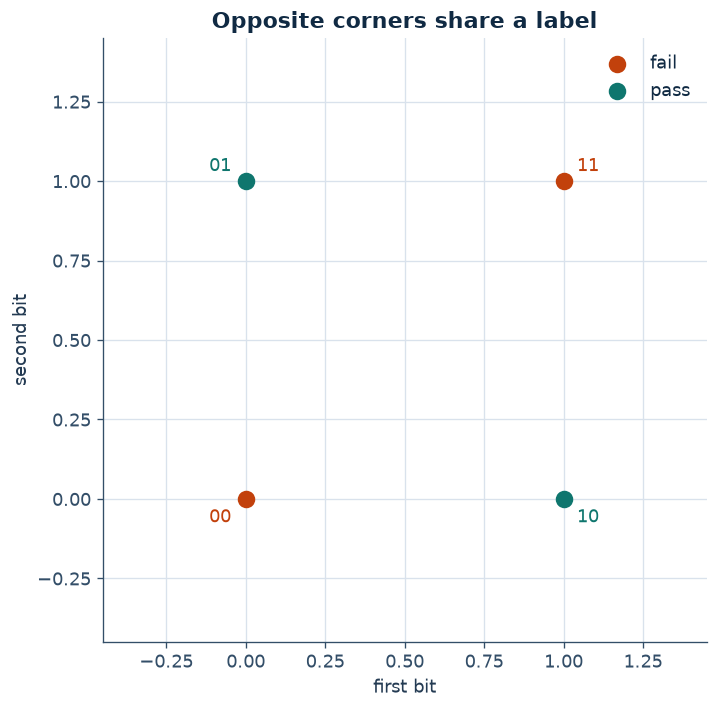

In [2]:
import matplotlib.pyplot as plt

# Pass is green, fail is clay, and a learned line is blue.
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"

# Opposite corners share a label, so no single straight cut works.
fig, ax = plt.subplots(figsize=(6.4, 5.8), constrained_layout=True)
ax.scatter([0, 1], [0, 1], s=90, color=CLAY, zorder=3, label="fail")
ax.scatter([1, 0], [0, 1], s=90, color=GREEN, zorder=3, label="pass")
ax.annotate("00", (0, 0), textcoords="offset points", xytext=(-22, -14), color=CLAY)
ax.annotate("10", (1, 0), textcoords="offset points", xytext=(8, -14), color=GREEN)
ax.annotate("01", (0, 1), textcoords="offset points", xytext=(-22, 6), color=GREEN)
ax.annotate("11", (1, 1), textcoords="offset points", xytext=(8, 6), color=CLAY)
ax.set_xlim(-0.45, 1.45)
ax.set_ylim(-0.45, 1.45)
ax.set_aspect("equal")
ax.set_xlabel("first bit")
ax.set_ylabel("second bit")
ax.set_title("Opposite corners share a label")
ax.legend(frameon=False)


## Pitfall — A cycle is not a slow success

After four updates the weights are the weights from the start. More epochs repeat the cycle. They do not approach a line that the inequalities already forbade.


## Summary

Adding the pass inequalities and comparing them with the two fail inequalities is a contradiction. The update rule, started at zero on the order 00, 10, 01, 11, returns to zero after four updates and then repeats.
